# Reinforcement learning challenges: solutions

In this notebook you will teach a robot to find treasure, and complete some short challenges along the way.

The robot is never told where the treasure is. It has to learn by **trying moves and getting rewards**. That is reinforcement learning.

**How to use this notebook**

- Run each cell in order with **Shift + Enter**.
- Cells marked **Challenge** need you to do something. Most just need you to replace `___` with the right value, or answer a question in a text cell.
- Some cells check your answer for you and print *Correct* or *Not quite*.
- If something breaks, use **Kernel > Restart & Run All** and work down from the top again.

*This copy has every challenge completed, with answers in the text cells.*

## Key words

| Word | Meaning in our game |
|---|---|
| **Agent** | The robot, the thing that learns |
| **Environment** | The corridor the robot lives in |
| **State** | Which square the robot is on |
| **Action** | Move left or move right |
| **Reward** | Points the robot gets after each move |
| **Episode** | One full game, from the start until it ends |

## Part 1: The world

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)   # random numbers with a fixed seed, so results can be repeated

The robot lives in a corridor of 8 squares, numbered 0 to 7.

- The robot **starts on square 2**.
- Square 0 is a **trap**: landing there costs **-10** points and ends the game.
- Square 7 is the **treasure**: landing there gives **+10** points and ends the game.
- Every other move costs **-1** point, so quick routes are better.

In [2]:
N_SQUARES = 8
START = 2
TRAP = 0
TREASURE = 7
ACTIONS = ["left", "right"]

def show(robot):
    row = ""
    for square in range(N_SQUARES):
        if square == robot:
            row += "[ R ]"
        elif square == TRAP:
            row += "[ T ]"
        elif square == TREASURE:
            row += "[ $ ]"
        else:
            row += "[   ]"
    print(row)

show(START)
print("R = robot,  T = trap,  $ = treasure")

[ T ][   ][ R ][   ][   ][   ][   ][ $ ]
R = robot,  T = trap,  $ = treasure


### Challenge 1: think first

Without writing any code:

a) What is the **fewest number of moves** the robot needs to reach the treasure from square 2?

b) What would its **total reward** be if it took that route? (Remember: -1 for each ordinary move, +10 for the move onto the treasure.)

**Answer:** a) 5 moves: from square 2 to 3, 4, 5, 6 and then 7. b) The first 4 moves cost -1 each and the last move earns +10, so the total is -4 + 10 = **6**.

### Challenge 2: draw the robot

Use the `show` function to draw the robot on **square 5**.

In [3]:
show(5)

[ T ][   ][   ][   ][   ][ R ][   ][ $ ]


## Part 2: The rules of the game

The `step` function is the environment. We give it the robot's square and an action. It gives back three things:

- the **new square**
- the **reward** for that move
- whether the game is **done** (True or False)

### Challenge 3: finish the rules

The treasure rule is written for you. Fill in the two blanks so that landing on the **trap** gives a reward of **-10** and ends the game. Then run the check cell underneath.

In [4]:
def step(square, action):
    if action == "left":
        new_square = square - 1
    else:
        new_square = square + 1

    if new_square == TREASURE:
        return new_square, 10, True
    if new_square == TRAP:
        return new_square, -10, True
    return new_square, -1, False

In [5]:
# Check cell: just run this
if step(1, "left") == (0, -10, True) and step(6, "right") == (7, 10, True) and step(3, "right") == (4, -1, False):
    print("Correct! The rules work.")
else:
    print("Not quite. Check the two blanks in the step function.")

Correct! The rules work.


### Challenge 4: move the robot yourself

The code below makes **one** move to the right and adds up the reward. Add **two more** moves to the right, so the robot moves three times in total.

In [6]:
square = START
total = 0

square, reward, done = step(square, "right")
total = total + reward

square, reward, done = step(square, "right")
total = total + reward

square, reward, done = step(square, "right")
total = total + reward

print("Robot is on square", square, "with a total reward of", total)
show(square)

Robot is on square 5 with a total reward of -3
[ T ][   ][   ][   ][   ][ R ][   ][ $ ]


How many more moves does the robot need to reach the treasure from here, and what would its final total reward be?

**Answer:** The robot is on square 5 with -3. It needs **2 more** moves: one to square 6 (-1) and one onto the treasure (+10). The final total is -3 - 1 + 10 = **6**, the same as Challenge 1.

## Part 3: A robot that moves at random

Before any learning, let's see how a robot does if it picks left or right at random every time. This function plays one whole game and returns the **square it ended on**, its **total reward** and the **number of moves**.

In [7]:
def play_randomly(start=START):
    square = start
    total = 0
    moves = 0
    done = False
    while not done:
        action = str(rng.choice(ACTIONS))
        square, reward, done = step(square, action)
        total = total + reward
        moves = moves + 1
    return square, total, moves

print(play_randomly())

(0, -17, 8)


### Challenge 5: how often does a random robot win?

Fill in the blank so the code counts how many of 1,000 random games end on the **treasure** square.

In [8]:
rng = np.random.default_rng(0)
treasure_count = 0

for game in range(1000):
    end_square, total, moves = play_randomly()
    if end_square == TREASURE:
        treasure_count = treasure_count + 1

print("Found the treasure in", treasure_count, "out of 1000 games")

Found the treasure in 296 out of 1000 games


### Challenge 6: predict, then test

If the random robot started on **square 5** instead of square 2, would it find the treasure **more often** or **less often**? Write your prediction first, then fill in the blank to test it.

**Answer:** **More often.** From square 5 the treasure is only 2 squares away and the trap is 5 squares away, so a random walk is much more likely to hit the treasure first. From square 2 it is the other way round.

In [9]:
rng = np.random.default_rng(0)
treasure_count = 0

for game in range(1000):
    end_square, total, moves = play_randomly(start=5)
    if end_square == TREASURE:
        treasure_count = treasure_count + 1

print("Starting on square 5: found the treasure in", treasure_count, "out of 1000 games")

Starting on square 5: found the treasure in 726 out of 1000 games


Starting on square 2 the random robot wins only about 2 games in 7 (about 29%). Starting on square 5 it wins about 5 games in 7 (about 71%). Either way, it never gets any better, because it has no memory.

## Part 4: Giving the robot a memory

The robot keeps a table called a **Q-table**. There is one row for each square and one column for each action. Each number is the robot's guess at **how good that move is from that square**. At the start every score is 0, because it knows nothing yet.

In [10]:
def make_q_table():
    table = pd.DataFrame(0.0, index=range(N_SQUARES), columns=ACTIONS)
    table.index.name = "square"
    return table

Q = make_q_table()
Q

,left,right
square,,
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0


### Challenge 7: reading and writing the table

`Q.loc[square, action]` gets or sets one score. Set the score for moving **right** from **square 6** to **10**, then look at that row.

In [11]:
Q.loc[6, "right"] = 10
print(Q.loc[6])

left      0.0
right    10.0
Name: 6, dtype: float64


Now put the table back to all zeros before we start learning.

In [12]:
Q = make_q_table()

## Part 5: How the robot chooses a move

The robot has to balance two things:

- **Exploit**: pick the move with the highest score (use what it knows).
- **Explore**: sometimes pick a random move (try something new).

**Epsilon** is how often it explores. With `epsilon=0.1` it explores 10% of the time. If two moves have the same score, it picks between them at random.

In [13]:
def choose_action(Q, square, epsilon=0.1):
    if rng.random() < epsilon:
        return str(rng.choice(ACTIONS))                 # explore
    scores = Q.loc[square]
    best = [a for a in ACTIONS if scores[a] == scores.max()]
    return str(rng.choice(best))                        # exploit

### Challenge 8: how often does it pick the worse move?

On square 4, suppose **right** scores 5 and **left** scores 0, so right is clearly better.

a) Out of 1,000 choices with `epsilon=0.1`, roughly how many times do you think the robot will choose **left**? (Hint: when it explores, it picks left or right at random.)

b) Fill in the blank to count them and check.

**Answer:** a) It explores 10% of the time, which is about 100 choices out of 1,000. When it explores, it picks left half the time, so we expect about **50** lefts.

In [14]:
rng = np.random.default_rng(0)
test_Q = make_q_table()
test_Q.loc[4, "right"] = 5

lefts = 0
for i in range(1000):
    if choose_action(test_Q, 4, epsilon=0.1) == "left":
        lefts = lefts + 1

print("Chose left", lefts, "times out of 1000")

Chose left 47 times out of 1000


## Part 6: How the robot learns

After every move, the robot updates one score in its table:

> **new score = old score + 0.5 × (target − old score)**

> **target = reward + 0.9 × (best score from the new square)**

In words: *"what I got now, plus how good the place I ended up is"*. The robot moves its old score halfway towards that target.

- **0.5** is the **learning rate**: how big a step it takes towards the target.
- **0.9** is the **discount**: future rewards count a little less than rewards now.
- If the game has ended, there is no future, so the **target is just the reward**.

### Challenge 9: work it out by hand

The robot is on square 6 and moves right onto the treasure (reward +10, game over). The old score for that move is 0.

a) What is the new score after this happens **once**?

b) It happens again. What is the score after the **second** time?

c) And after the **third** time?

**Answer:** a) target = 10, so new score = 0 + 0.5 × (10 − 0) = **5**. b) 5 + 0.5 × (10 − 5) = **7.5**. c) 7.5 + 0.5 × (10 − 7.5) = **8.75**. Each time it closes half of the remaining gap, so it creeps closer and closer to 10.

### Challenge 10: finish the learning rule

Fill in the blank in the `else` part: the **best score from the new square**. (Hint: `Q.loc[new_square]` is the whole row for that square. What pandas function gives the biggest value in it?)

In [15]:
LEARNING_RATE = 0.5
DISCOUNT = 0.9

def learn(Q, square, action, reward, new_square, done):
    old = Q.loc[square, action]
    if done:
        target = reward
    else:
        target = reward + DISCOUNT * Q.loc[new_square].max()
    Q.loc[square, action] = old + LEARNING_RATE * (target - old)

In [16]:
# Check cell: just run this
test_Q = make_q_table()
for i in range(3):
    learn(test_Q, 6, "right", 10, 7, True)
    print("After time", i + 1, "the score is", test_Q.loc[6, "right"])

test_Q.loc[6, "right"] = 10
learn(test_Q, 5, "right", -1, 6, False)
if test_Q.loc[5, "right"] == 4:
    print("Correct! Do the first three numbers match your answers to Challenge 9?")
else:
    print("Not quite. Check the blank in the learn function.")

After time 1 the score is 5.0
After time 2 the score is 7.5
After time 3 the score is 8.75
Correct! Do the first three numbers match your answers to Challenge 9?


For the check: on square 5 the target is -1 + 0.9 × 10 = 8, so the new score is 0 + 0.5 × (8 − 0) = 4.

## Part 7: Training the robot

Here is a full game with learning switched on, and a `train` function that plays lots of games. You do not need to change these, but read through `play_and_learn` and see if you can spot each idea from the parts above.

In [17]:
def play_and_learn(Q, epsilon=0.1):
    square = START
    moves = 0
    done = False
    while not done:
        action = choose_action(Q, square, epsilon)                 # Part 5: choose
        new_square, reward, done = step(square, action)            # Part 2: act
        learn(Q, square, action, reward, new_square, done)         # Part 6: learn
        square = new_square
        moves = moves + 1
    return moves, square


def train(games=100, epsilon=0.1, seed=0):
    global rng
    rng = np.random.default_rng(seed)     # same seed, same results
    Q = make_q_table()                    # start with an empty memory
    moves_list = []
    end_squares = []
    for game in range(games):
        moves, end = play_and_learn(Q, epsilon)
        moves_list.append(moves)
        end_squares.append(end)
    return Q, moves_list, end_squares

### Challenge 11: is it getting better?

Train the robot for 100 games. Then fill in the blanks to get the average number of moves in the **first 10** games and in the **last 10** games. (Hint: `my_list[:3]` gives the first 3 items of a list and `my_list[-3:]` gives the last 3.)

In [18]:
Q, moves_list, end_squares = train(games=100)

first_10_average = np.mean(moves_list[:10])
last_10_average = np.mean(moves_list[-10:])

print("Average moves, first 10 games:", first_10_average)
print("Average moves, last 10 games: ", last_10_average)

Average moves, first 10 games: 7.5
Average moves, last 10 games:  5.6


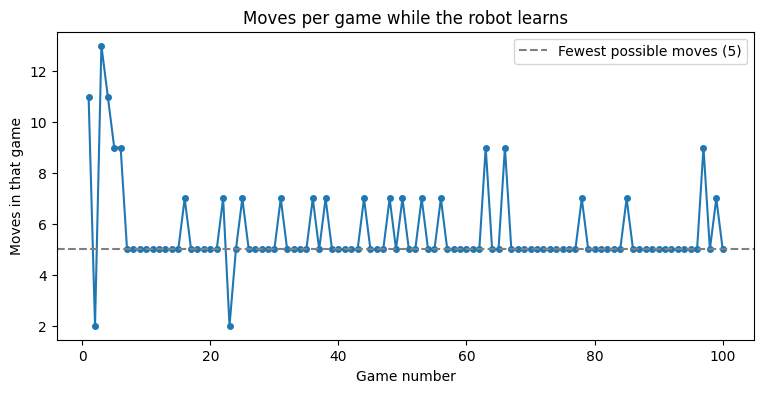

In [19]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(moves_list) + 1), moves_list, marker="o", markersize=4)
plt.axhline(5, color="grey", linestyle="--", label="Fewest possible moves (5)")
plt.xlabel("Game number")
plt.ylabel("Moves in that game")
plt.title("Moves per game while the robot learns")
plt.legend()
plt.show()

Why do some later games still take 7 or 9 moves, even though the robot has already learned the way?

**Answer:** The robot still **explores** 10% of the time. When it takes a random step to the left by mistake, it then has to walk back, which adds 2 moves each time.

### Challenge 12: what has it learned?

Look at the Q-table, then fill in the blank to print the best move on each middle square. (Hint: `idxmax()` gives the **name** of the column with the highest value, where `max()` gives the value itself.)

In [20]:
Q.round(2)

,left,right
square,,
0,0.00,0.00
1,-7.50,1.26
2,-1.30,3.12
3,1.59,4.58
4,2.98,6.20
5,3.94,8.00
6,6.07,10.00
7,0.00,0.00


In [21]:
for square in range(1, TREASURE):
    best = Q.loc[square].idxmax()
    print("Square", square, "best move:", best)

Square 1 best move: right
Square 2 best move: right
Square 3 best move: right
Square 4 best move: right
Square 5 best move: right
Square 6 best move: right


Look down the **right** column of the Q-table. What do you notice about the scores as the squares get closer to the treasure? Why does this happen?

**Answer:** The scores get **bigger** the closer the square is to the treasure. Each extra step costs -1, and future rewards are multiplied by 0.9 for every step away, so being one step from the treasure is worth more than being five steps away.

Now watch the trained robot play one game with exploring switched off.

In [22]:
square = START
done = False
show(square)
while not done:
    action = choose_action(Q, square, epsilon=0)
    square, reward, done = step(square, action)
    show(square)
print("Reached the treasure!" if square == TREASURE else "Fell in the trap.")

[ T ][   ][ R ][   ][   ][   ][   ][ $ ]
[ T ][   ][   ][ R ][   ][   ][   ][ $ ]
[ T ][   ][   ][   ][ R ][   ][   ][ $ ]
[ T ][   ][   ][   ][   ][ R ][   ][ $ ]
[ T ][   ][   ][   ][   ][   ][ R ][ $ ]
[ T ][   ][   ][   ][   ][   ][   ][ R ]
Reached the treasure!


## Part 8: Experiments

### Challenge 13: a very curious robot

Train a new robot that explores **half** the time (`epsilon=0.5`). Fill in the blank, then compare the average moves in its last 10 games with your answer to Challenge 11.

In [23]:
Q_curious, moves_curious, ends_curious = train(games=100, epsilon=0.5)

print("Average moves, last 10 games:", np.mean(moves_curious[-10:]))
print("Games that ended in the trap:", ends_curious.count(TRAP))

Average moves, last 10 games:

 9.1
Games that ended in the trap: 10


Why does the curious robot keep taking more moves, even after 100 games?

**Answer:** It still takes a random move half of the time, so it keeps wandering off the best route, even if its Q-table already knows the way. Some of those random steps near the start even take it into the trap. Exploring helps it discover things early on, but too much exploring wastes moves. Real systems often explore a lot at the start and then less and less over time.

### Challenge 14 (bonus): not enough practice

Train a robot for only **3** games. Does it already know the best move on every square? Fill in both blanks.

In [24]:
Q_short, moves_short, ends_short = train(games=3)

for square in range(1, TREASURE):
    print("Square", square, "best move:", Q_short.loc[square].idxmax())

Q_short.round(2)

Square 1 best move: right
Square 2 best move: left
Square 3 best move: left
Square 4 best move: left
Square 5 best move: right
Square 6 best move: right


,left,right
square,,
0,0.00,0.00
1,-5.00,-1.36
2,-1.20,-1.27
3,-1.09,-1.10
4,-0.84,-1.21
5,-0.84,1.38
6,-0.50,7.50
7,0.00,0.00


**Answer:** No. After only 3 games it thinks **left** is the best move on squares 2, 3 and 4, which is wrong. Look at the table: the scores on those squares are small negative numbers that are very close together, because the robot has not yet reached the treasure often enough for the good news to spread back to them. It needs more practice before its table is reliable.

## Summary

| Idea | What it means |
|---|---|
| Environment | The corridor and its rules (the `step` function) |
| Reward | +10 treasure, -10 trap, -1 for every other move |
| Q-table | The robot's memory: a score for each move on each square |
| Explore and exploit | Mostly pick the best move, sometimes try a random one |
| Learning rule | Move the score halfway towards *reward + 0.9 × best next score* |
| Training | After a few games the robot goes straight to the treasure |

### Final question

In one or two sentences, explain how the robot learned to find the treasure **without ever being told where it was**.

**Answer:** It tried moves, got rewards or penalties, and stored what happened as scores in its Q-table. Moves that led towards the treasure built up high scores and moves that led to the trap got low scores, so by picking the highest-scoring move it ended up taking the best route.